# 04 - Preprocessing e Feature Engineering

## Obiettivo del notebook

In questo notebook costruiamo una prima versione del dataset arricchita con feature ingegnerizzate e interpretabili.

L'obiettivo non è scegliere il modello finale, ma:

- partire dai risultati della feature comprehension;
- costruire nuove feature coerenti con il significato fisico e strutturale delle variabili;
- confrontare dataset originale e dataset arricchito;
- osservare il comportamento delle nuove feature rispetto a `damage_grade`;
- produrre indicazioni operative per preprocessing, feature selection e modellazione.

Le trasformazioni stabili sono implementate in `src/features.py` e richiamate da `src/preprocessing.py`.

Questo notebook rappresenta una fase intermedia: prepara il dataset e propone feature candidate, ma non effettua ancora model comparison, tuning o valutazione finale.


## 1. Import e setup

Importiamo le librerie principali e i moduli riutilizzabili del progetto.

Il blocco `PROJECT_ROOT` permette di eseguire il notebook sia dalla cartella `notebooks/` sia dalla root del repository.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_full_train, load_train_test
from src.features import add_engineered_features, get_feature_group_summary
from src.preprocessing import prepare_features, infer_column_groups

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid')


## 2. Caricamento dati

Carichiamo il dataset di training completo, ottenuto dal merge tra `train_values.csv` e `train_labels.csv` tramite `building_id`.

Separiamo poi:

- `X`: feature del training set;
- `y`: target `damage_grade`;
- `test_values`: feature del test set;
- `submission_format`: formato richiesto per eventuale submission.


In [2]:
train = load_full_train()
X, y, test_values, submission_format = load_train_test()

print('Train completo:', train.shape)
print('X:', X.shape)
print('y:', y.shape)
print('Test:', test_values.shape)
print('Submission format:', submission_format.shape)

train.head()


Train completo: (260601, 40)
X: (260601, 39)
y: (260601,)
Test: (86868, 39)
Submission format: (86868, 2)


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3


## 3. Riepilogo gruppi di feature

Riprendiamo la classificazione delle feature discussa nel notebook 03.

I gruppi principali sono:

- feature geografiche;
- feature numeriche strutturali;
- feature categoriche strutturali;
- feature binarie di superstruttura;
- feature binarie di uso secondario.


In [3]:
feature_group_summary = get_feature_group_summary(X)
feature_group_summary


,group,n_features
0,geographical,3
1,numeric_structural,5
2,categorical_structural,8
3,superstructure_binary,11
4,secondary_use_binary,10


## 4. Feature engineering

Aggiungiamo feature semplici e interpretabili:

- `total_superstructure_count`: numero totale di materiali/tecniche strutturali presenti;
- `total_secondary_use_count`: numero totale di usi secondari specifici;
- `has_fragile_material`: presenza di materiali potenzialmente fragili;
- `has_engineered_structure`: presenza di strutture più ingegnerizzate;
- `building_volume_proxy`: proxy dimensionale basata su area e altezza;
- `age_clipped`: età limitata superiormente per gestire valori estremi;
- `age_group`: classi di età dell'edificio.

Queste feature sono state scelte perché sono interpretabili e coerenti con il significato strutturale delle variabili originali.


In [4]:
X_engineered = add_engineered_features(X)
new_columns = sorted(set(X_engineered.columns) - set(X.columns))

print('Numero feature originali:', X.shape[1])
print('Numero feature dopo engineering:', X_engineered.shape[1])
print('Nuove feature:')
for col in new_columns:
    print('-', col)

X_engineered[new_columns].head()


Numero feature originali: 39
Numero feature dopo engineering: 46
Nuove feature:
- age_clipped
- age_group
- building_volume_proxy
- has_engineered_structure
- has_fragile_material
- total_secondary_use_count
- total_superstructure_count


,age_clipped,age_group,building_volume_proxy,has_engineered_structure,has_fragile_material,total_secondary_use_count,total_superstructure_count
0,30,11_30,30,0,1,0,2
1,10,0_10,56,0,1,0,1
2,10,0_10,25,0,1,0,1
3,10,0_10,30,0,1,0,3
4,30,11_30,72,0,1,0,1


## 5. Analisi di `age` e valori estremi

Nel dataset è presente il valore anomalo `age = 995`.

Questo valore può influenzare statistiche descrittive, scaling e modelli sensibili alla scala. Per questo viene creata `age_clipped`, limitando l'età massima a 200.

La scelta non elimina l'informazione sull'età, ma riduce l'effetto degli outlier estremi.


In [5]:
age_summary = X_engineered[['age', 'age_clipped']].describe().T
age_995_count = int((X_engineered['age'] == 995).sum())
age_995_percentage = age_995_count / len(X_engineered) * 100

print('Numero edifici con age = 995:', age_995_count)
print(f'Percentuale edifici con age = 995: {age_995_percentage:.2f}%')

age_summary


Numero edifici con age = 995: 1390
Percentuale edifici con age = 995: 0.53%


,count,mean,std,min,25%,50%,75%,max
age,260601.0,26.535029,73.565937,0.0,10.0,15.0,30.0,995.0
age_clipped,260601.0,22.294638,23.488691,0.0,10.0,15.0,30.0,200.0


### Interpretazione preliminare su `age`

Il valore `age = 995` è chiaramente anomalo rispetto alla distribuzione generale della variabile.

La feature `age_clipped` consente di mantenere il segnale informativo dell'età, evitando però che pochi valori estremi dominino la scala della variabile.

Nelle fasi successive si potrà valutare se usare:

- solo `age_clipped`;
- sia `age` sia `age_clipped`;
- `age_group` come versione categorica dell'età.


## 6. Statistiche descrittive delle nuove feature

Osserviamo distribuzione e valori principali delle feature costruite.


In [6]:
engineered_description = X_engineered[new_columns].describe(include='all').T
engineered_description


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age_clipped,260601.0,NaN,NaN,NaN,22.294638,23.488691,0.0,10.0,15.0,30.0,200.0
age_group,260601,5,11_30,110586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
building_volume_proxy,260601.0,NaN,NaN,NaN,45.229968,36.987169,2.0,25.0,36.0,55.0,2600.0
has_engineered_structure,260601.0,NaN,NaN,NaN,0.130176,0.336498,0.0,0.0,0.0,0.0,1.0
has_fragile_material,260601.0,NaN,NaN,NaN,0.863596,0.343218,0.0,1.0,1.0,1.0,1.0
total_secondary_use_count,260601.0,NaN,NaN,NaN,0.114017,0.324488,0.0,0.0,0.0,0.0,2.0
total_superstructure_count,260601.0,NaN,NaN,NaN,1.460002,0.776945,1.0,1.0,1.0,2.0,8.0


## 7. Relazione preliminare con il target

Uniamo temporaneamente le feature ingegnerizzate con `damage_grade` per osservare relazioni descrittive.

Questa analisi non misura ancora l'impatto sui modelli, ma aiuta a capire se le nuove feature hanno un comportamento coerente rispetto al danno.


In [7]:
engineered_train = X_engineered.copy()
engineered_train['damage_grade'] = y.values

target_summary = engineered_train.groupby('damage_grade')[new_columns].mean(numeric_only=True).T
target_summary


damage_grade,1,2,3
age_clipped,11.656384,22.934358,24.271653
building_volume_proxy,54.916813,45.190302,42.507005
has_engineered_structure,0.479223,0.127466,0.034236
has_fragile_material,0.385289,0.878247,0.976473
total_secondary_use_count,0.171708,0.121632,0.084455
total_superstructure_count,1.422664,1.500212,1.402405


### Prime osservazioni

Le feature più interessanti da osservare sono:

- `has_fragile_material`: dovrebbe aumentare al crescere del danno;
- `has_engineered_structure`: dovrebbe essere più frequente negli edifici meno danneggiati;
- `age_clipped`: può indicare maggiore vulnerabilità degli edifici più vecchi;
- `building_volume_proxy`: può catturare una componente dimensionale dell'edificio.

Queste osservazioni andranno poi validate quantitativamente nella feature selection e nella modellazione.


## 8. Visualizzazione delle feature continue e di conteggio

Per feature numeriche continue o di conteggio usiamo boxplot rispetto a `damage_grade`.


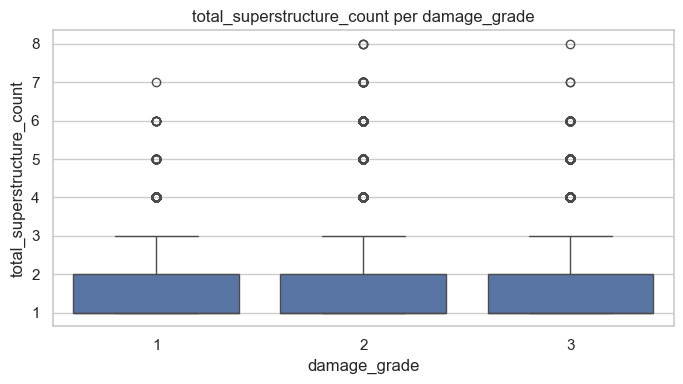

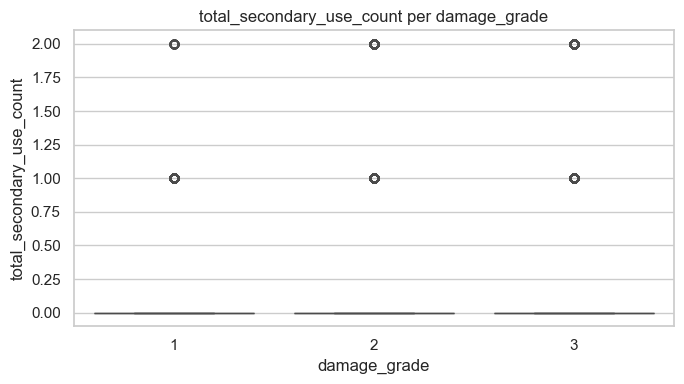

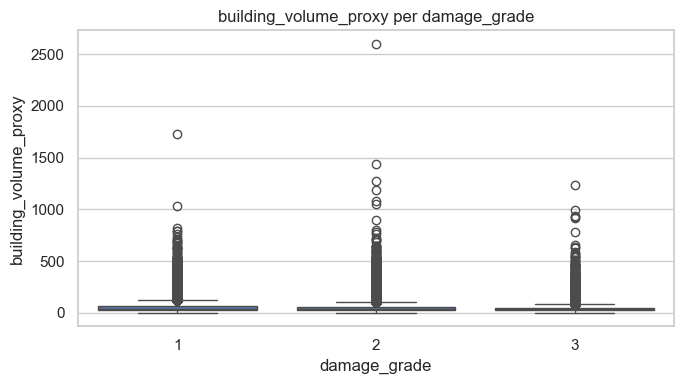

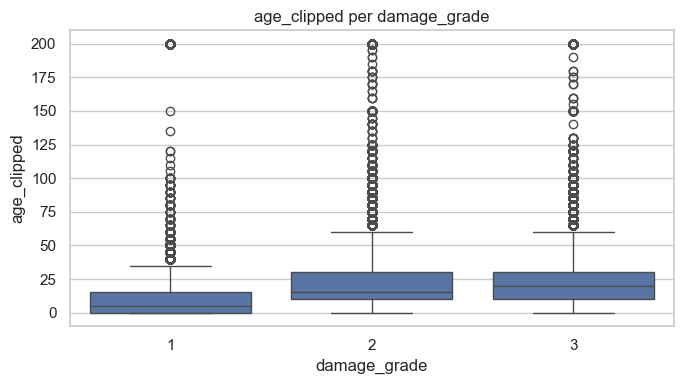

In [8]:
continuous_plot_cols = [
    col for col in [
        'total_superstructure_count',
        'total_secondary_use_count',
        'building_volume_proxy',
        'age_clipped',
    ] if col in engineered_train.columns
]

for col in continuous_plot_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=engineered_train, x='damage_grade', y=col)
    plt.title(f'{col} per damage_grade')
    plt.xlabel('damage_grade')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## 9. Visualizzazione delle feature binarie

Per feature binarie ha più senso osservare la frequenza media per classe di danno.

Un valore medio vicino a 1 indica che la caratteristica è molto frequente in quella classe; un valore vicino a 0 indica che è rara.


,damage_grade,feature,frequency
0,1,has_fragile_material,0.385289
1,2,has_fragile_material,0.878247
2,3,has_fragile_material,0.976473
3,1,has_engineered_structure,0.479223
4,2,has_engineered_structure,0.127466
5,3,has_engineered_structure,0.034236


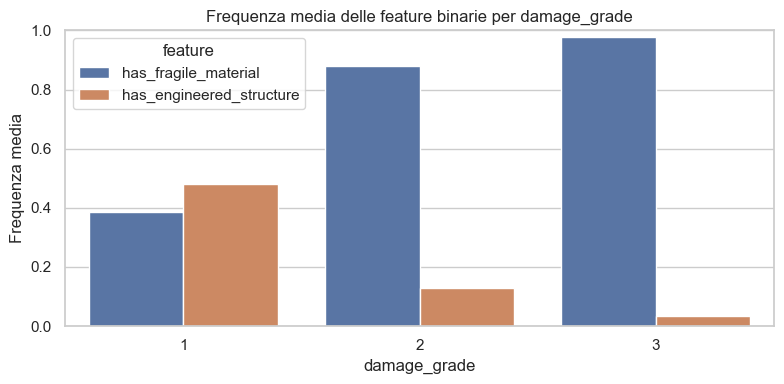

In [9]:
binary_plot_cols = [
    col for col in [
        'has_fragile_material',
        'has_engineered_structure',
    ] if col in engineered_train.columns
]

binary_rates = (
    engineered_train
    .groupby('damage_grade')[binary_plot_cols]
    .mean()
    .reset_index()
    .melt(id_vars='damage_grade', var_name='feature', value_name='frequency')
)

plt.figure(figsize=(8, 4))
sns.barplot(data=binary_rates, x='damage_grade', y='frequency', hue='feature')
plt.title('Frequenza media delle feature binarie per damage_grade')
plt.xlabel('damage_grade')
plt.ylabel('Frequenza media')
plt.ylim(0, 1)
plt.tight_layout()
display(binary_rates)



## 10. Preparazione feature per modellazione

Usiamo `prepare_features` per applicare le trasformazioni definite nel codice riutilizzabile.

Verifichiamo anche quali colonne vengono trattate come categoriche e quali come numeriche.

Le feature geografiche vengono trattate come categoriche, non come grandezze numeriche continue.


In [10]:
X_prepared = prepare_features(X)
categorical_cols, numeric_cols = infer_column_groups(X_prepared)

print('Shape dopo prepare_features:', X_prepared.shape)
print('Numero colonne categoriche:', len(categorical_cols))
print('Numero colonne numeriche:', len(numeric_cols))

print('\nColonne categoriche:')
print(categorical_cols)

print('\nPrime colonne numeriche:')
print(numeric_cols[:30])


Shape dopo prepare_features: (260601, 45)
Numero colonne categoriche: 12
Numero colonne numeriche: 33

Colonne categoriche:
['age_group', 'foundation_type', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'ground_floor_type', 'land_surface_condition', 'legal_ownership_status', 'other_floor_type', 'plan_configuration', 'position', 'roof_type']

Prime colonne numeriche:
['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'ha

## 11. Conclusioni operative

Dall'analisi preliminare delle feature ingegnerizzate emergono alcune indicazioni utili per le fasi successive.

La feature `has_fragile_material` è particolarmente rilevante dal punto di vista interpretativo: rappresenta la presenza di materiali potenzialmente fragili e dovrebbe essere associata a una maggiore vulnerabilità strutturale. Se la sua frequenza aumenta nelle classi di danno più elevate, questo conferma la coerenza della feature rispetto al problema.

La feature `has_engineered_structure` ha invece un significato opposto: indica la presenza di componenti strutturali più ingegnerizzate. Una maggiore frequenza negli edifici con danno basso sarebbe coerente con l'ipotesi che strutture più robuste siano meno vulnerabili.

La variabile `age` contiene valori estremi, in particolare `age = 995`. Per questo è stata introdotta `age_clipped`, che limita l'età massima a 200. Questa trasformazione riduce l'effetto degli outlier mantenendo l'informazione principale sull'età dell'edificio.

`building_volume_proxy`, costruita come prodotto tra `area_percentage` e `height_percentage`, fornisce una proxy dimensionale dell'edificio. Il suo contributo dovrà essere verificato nei modelli, perché la relazione con il danno potrebbe non essere lineare.

Per le fasi successive si propone di mantenere nel dataset arricchito:

- `has_fragile_material`;
- `has_engineered_structure`;
- `age_clipped`;
- `age_group`;
- `building_volume_proxy`;
- `total_superstructure_count`;
- `total_secondary_use_count`.

La feature selection dovrà verificare quantitativamente l'impatto di queste variabili sulla micro-F1. La PCA verrà considerata solo come esperimento secondario dopo encoding e scaling, non come componente centrale della pipeline.
